# Lab 9: Clustering, Dimensionality Reduction & Hyperparameter Tuning

This is Lab 9, covering advanced unsupervised learning techniques and model optimization strategies using real-world customer data.

**Dataset**: Online Retail Dataset (Kaggle) - Customer transactions data perfect for segmentation and anomaly detection

**Topics Covered**:
1. K-Means Clustering and Hierarchical Clustering
2. Principal Component Analysis (PCA) and Dimensionality Reduction
3. Lab: Customer Segmentation
4. Lab: Anomaly Detection
5. Cross-validation Strategies
6. Hyperparameter Tuning: Grid Search vs Random Search
7. When Tuning is a Waste of Time
8. Lab: Structured Hyperparameter Experiments

In [ ]:
# Install required packages
%pip install -q pandas numpy matplotlib seaborn scikit-learn scipy plotly kaggle

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')
import time

# Set random seed
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Data Loading

We'll use an Online Retail dataset. You can download it from Kaggle or from UCI.

**Dataset Option 1 (Kaggle, working):**
```bash
kaggle datasets download -d carrie1/ecommerce-data
```

**Dataset Option 2 (UCI original source):**
https://archive.ics.uci.edu/dataset/352/online+retail

Direct ZIP download:
https://archive.ics.uci.edu/static/public/352/online+retail.zip

**Dataset Option 3**: We'll create synthetic customer transaction data similar to the Online Retail dataset

In [37]:
# Option 1: Load from CSV if you have downloaded the dataset
# df = pd.read_csv('OnlineRetail.csv', encoding='iso-8859-1')

# Option 2: Create synthetic dataset for demo purposes
# (Similar structure to Online Retail Dataset)
np.random.seed(42)
n_customers = 1000
n_transactions_per_customer = np.random.randint(5, 50, n_customers)

data = []
for cust_id in range(n_customers):
    n_trans = n_transactions_per_customer[cust_id]
    for _ in range(n_trans):
        quantity = np.random.randint(1, 100)
        unit_price = np.random.uniform(0.5, 100)
        # Add some trend variations
        if cust_id % 3 == 0:  # High-value customers
            unit_price *= 2
        data.append({
            'CustomerID': cust_id,
            'Quantity': quantity,
            'UnitPrice': unit_price,
            'InvoiceDate': pd.Timestamp('2023-01-01') + pd.Timedelta(days=np.random.randint(0, 365))
        })

df = pd.DataFrame(data)
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset info:")
print(df.info())
print(f"\nBasic statistics:")
print(df.describe())

Dataset shape: (27000, 5)

First few rows:
   CustomerID  Quantity   UnitPrice InvoiceDate   TotalAmount
0           0        78  105.090020  2023-05-12   8197.021523
1           0        89  175.562908  2023-03-30  15625.098778
2           0        18  163.503288  2023-10-22   2943.059192
3           0        14  180.033822  2023-05-05   2520.473503
4           0        38  108.416431  2023-03-04   4119.824390

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 27000 entries, 0 to 26999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CustomerID   27000 non-null  int64         
 1   Quantity     27000 non-null  int64         
 2   UnitPrice    27000 non-null  float64       
 3   InvoiceDate  27000 non-null  datetime64[us]
 4   TotalAmount  27000 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(2)
memory usage: 1.0 MB
None

Basic statistics:
         CustomerID      Quantity    

## Feature Engineering for Customer Segmentation

We'll create RFM (Recency, Frequency, Monetary) features - a classic approach in customer analytics.

In [3]:
# Calculate RFM metrics
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'CustomerID': 'count',  # Frequency
    'TotalAmount': 'sum'  # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'CustomerID': 'Frequency',
    'TotalAmount': 'Monetary'
})

print(f"RFM Dataset shape: {rfm.shape}")
print(f"\nRFM Statistics:")
print(rfm.describe())
print(f"\nFirst few RFM records:")
print(rfm.head())

RFM Dataset shape: (1000, 3)

RFM Statistics:
           Recency    Frequency       Monetary
count  1000.000000  1000.000000    1000.000000
mean     19.226000    27.000000   91040.223615
std      25.694691    12.945562   58845.983637
min       1.000000     5.000000    2294.548147
25%       5.000000    16.000000   45864.533788
50%      10.000000    28.000000   80706.171909
75%      23.000000    38.000000  120087.961045
max     217.000000    49.000000  285824.571777

First few RFM records:
            Recency  Frequency       Monetary
CustomerID                                   
0                 2         43  194475.593473
1                 5         33   67395.552439
2                 7         19   42697.795953
3                 1         47  247072.307841
4                22         12   25425.878556


In [4]:
# Standardize RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)

print("Scaled RFM (first 5 rows):")
print(rfm_scaled_df.head())
print(f"\nMean of scaled features (should be ~0):")
print(rfm_scaled_df.mean())
print(f"\nStd of scaled features (should be ~1):")
print(rfm_scaled_df.std())

Scaled RFM (first 5 rows):
             Recency  Frequency  Monetary
CustomerID                               
0          -0.670746   1.236563  1.758610
1          -0.553932   0.463711 -0.402007
2          -0.476056  -0.618282 -0.821919
3          -0.709684   1.545704  2.652860
4           0.108014  -1.159278 -1.115576

Mean of scaled features (should be ~0):
Recency      4.174439e-17
Frequency    0.000000e+00
Monetary     8.171241e-17
dtype: float64

Std of scaled features (should be ~1):
Recency      1.0005
Frequency    1.0005
Monetary     1.0005
dtype: float64


# Part 1: K-Means Clustering

K-Means is one of the most popular clustering algorithms. Let's explore how it works and find the optimal number of clusters.

## The Elbow Method: Finding Optimal K

The elbow method helps us find the optimal number of clusters by looking at the within-cluster sum of squares (WCSS).

In [5]:
# Calculate WCSS for different K values
wcss = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    
    wcss.append(kmeans.inertia_)  # Within-cluster sum of squares
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(rfm_scaled, kmeans.labels_))
    calinski_harabasz_scores.append(calinski_harabasz_score(rfm_scaled, kmeans.labels_))

print("K-Means Evaluation Metrics:")
print("K\tWCSS\t\tSilhouette\tDavies-Bouldin\tCalinski-Harabasz")
for i, k in enumerate(K_range):
    print(f"{k}\t{wcss[i]:.2f}\t{silhouette_scores[i]:.4f}\t{davies_bouldin_scores[i]:.4f}\t{calinski_harabasz_scores[i]:.2f}")

K-Means Evaluation Metrics:
K	WCSS		Silhouette	Davies-Bouldin	Calinski-Harabasz
2	1616.76	0.4255	0.9273	853.87
3	1058.25	0.4198	0.8087	914.69
4	763.60	0.4038	0.7961	972.35
5	614.65	0.3707	0.8587	965.36
6	503.19	0.3716	0.8454	986.45
7	436.91	0.3802	0.8477	970.88
8	388.89	0.3757	0.8360	951.50
9	351.18	0.3307	0.8709	934.34
10	319.75	0.3448	0.8802	922.07


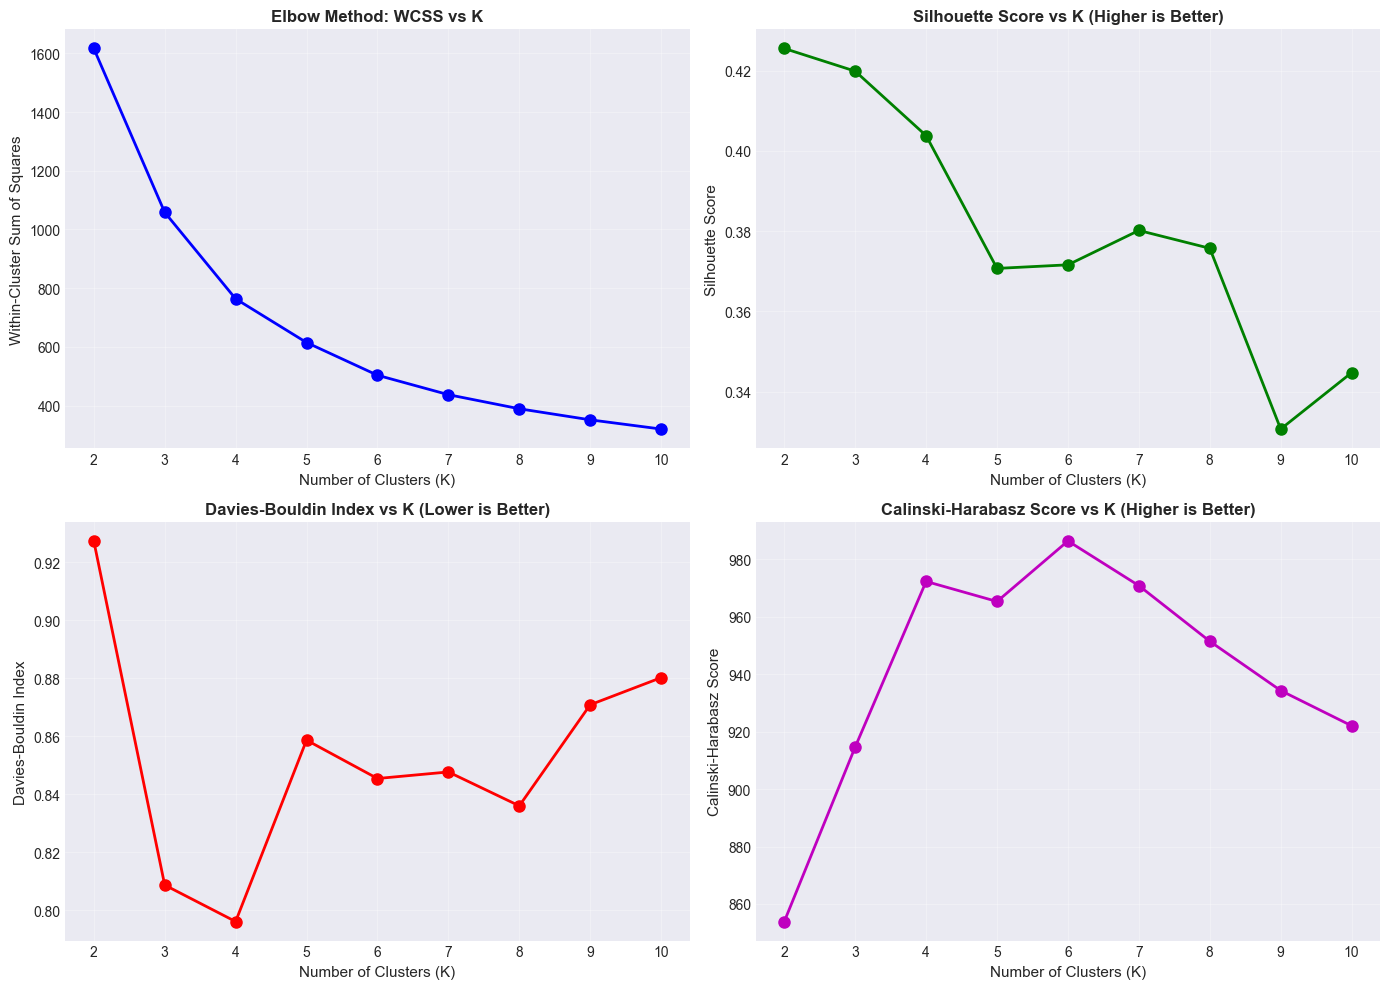


Optimal K based on Elbow Method: 10
Optimal K based on Silhouette Score: 2
Optimal K based on Davies-Bouldin Index: 4
Optimal K based on Calinski-Harabasz Score: 6


In [30]:
# Visualize the metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# WCSS (Elbow method)
axes[0, 0].plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0, 0].set_ylabel('Within-Cluster Sum of Squares', fontsize=11)
axes[0, 0].set_title('Elbow Method: WCSS vs K', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score (higher is better)
axes[0, 1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('Silhouette Score vs K (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Davies-Bouldin Index (lower is better)
axes[1, 0].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1, 0].set_title('Davies-Bouldin Index vs K (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Calinski-Harabasz Score (higher is better)
axes[1, 1].plot(K_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[1, 1].set_title('Calinski-Harabasz Score vs K (Higher is Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimal K based on Elbow Method: {K_range[np.argmin(wcss)]}")
print(f"Optimal K based on Silhouette Score: {K_range[np.argmax(silhouette_scores)]}")
print(f"Optimal K based on Davies-Bouldin Index: {K_range[np.argmin(davies_bouldin_scores)]}")
print(f"Optimal K based on Calinski-Harabasz Score: {K_range[np.argmax(calinski_harabasz_scores)]}")

## 🎯 Class Exercise 1: Interpret the Metrics

**Task**: Look at the four plots above and answer the following:

1. **What is the "elbow" in the WCSS plot?** Which K value would you choose and why?
2. **Compare the Silhouette Score and Davies-Bouldin plots.** Do they agree on the best K?
3. **Which metric would you trust most for this dataset and why?**
   - Hint: Silhouette measures compactness and separation
   - Davies-Bouldin measures average similarity between each cluster and its most similar cluster
   - Calinski-Harabasz measures the ratio of between-cluster to within-cluster dispersion

**Discussion**: In practice, you should use multiple metrics and domain knowledge. Don't rely on just one!

## Choosing K = 3 for Customer Segmentation

Based on the metrics and practical business use cases, we'll use K=3 (Good customers, At-risk, VIP customers).

In [7]:
# Final K-Means with K=3
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_clusters = kmeans_final.fit_predict(rfm_scaled)

# Add cluster labels to the original RFM data
rfm['KMeans_Cluster'] = kmeans_clusters

print(f"K-Means Clustering with K={optimal_k}")
print(f"\nCluster distribution:")
print(rfm['KMeans_Cluster'].value_counts().sort_index())
print(f"\nCluster percentages:")
print((rfm['KMeans_Cluster'].value_counts(normalize=True).sort_index() * 100).round(2))

K-Means Clustering with K=3

Cluster distribution:
KMeans_Cluster
0     92
1    463
2    445
Name: count, dtype: int64

Cluster percentages:
KMeans_Cluster
0     9.2
1    46.3
2    44.5
Name: proportion, dtype: float64


In [8]:
# Analyze cluster characteristics
print("\nCluster Characteristics (Original RFM Values):")
print("="*70)
for cluster in range(optimal_k):
    cluster_data = rfm[rfm['KMeans_Cluster'] == cluster]
    print(f"\nCluster {cluster}: n={len(cluster_data)} customers")
    print(cluster_data[['Recency', 'Frequency', 'Monetary']].describe().round(2))


Cluster Characteristics (Original RFM Values):

Cluster 0: n=92 customers
       Recency  Frequency   Monetary
count    92.00      92.00      92.00
mean     84.66       9.99   33071.68
std      35.09       4.97   20792.86
min      47.00       5.00    4670.86
25%      59.00       6.75   19194.33
50%      74.50       9.00   27371.67
75%      97.00      12.25   43704.17
max     217.00      33.00  133435.34

Cluster 1: n=463 customers
       Recency  Frequency   Monetary
count   463.00     463.00     463.00
mean      9.63      38.48  138009.24
std       9.19       6.56   50517.43
min       1.00      20.00   65132.22
25%       3.50      34.00   97982.25
50%       7.00      39.00  122103.64
75%      13.00      43.50  175643.73
max      71.00      49.00  285824.57

Cluster 2: n=445 customers
       Recency  Frequency   Monetary
count   445.00     445.00     445.00
mean     15.68      18.58   54155.84
std      12.22       7.67   26211.20
min       1.00       5.00    2294.55
25%       5.00    

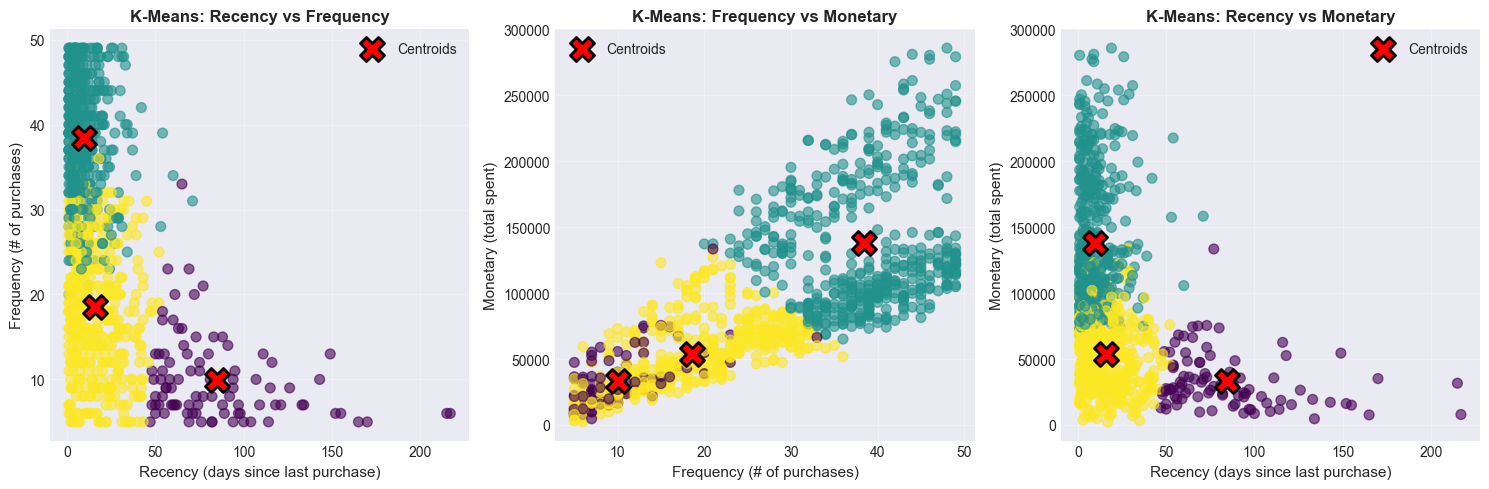

In [9]:
# Visualize K-Means clusters
fig = plt.figure(figsize=(15, 5))

# Recency vs Frequency
ax1 = fig.add_subplot(131)
scatter1 = ax1.scatter(rfm['Recency'], rfm['Frequency'], c=kmeans_clusters, 
                       cmap='viridis', alpha=0.6, s=50)
ax1.scatter(scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 0],
           scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 1],
           marker='X', s=300, c='red', edgecolors='black', linewidth=2, label='Centroids')
ax1.set_xlabel('Recency (days since last purchase)', fontsize=11)
ax1.set_ylabel('Frequency (# of purchases)', fontsize=11)
ax1.set_title('K-Means: Recency vs Frequency', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Frequency vs Monetary
ax2 = fig.add_subplot(132)
scatter2 = ax2.scatter(rfm['Frequency'], rfm['Monetary'], c=kmeans_clusters, 
                       cmap='viridis', alpha=0.6, s=50)
ax2.scatter(scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 1],
           scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 2],
           marker='X', s=300, c='red', edgecolors='black', linewidth=2, label='Centroids')
ax2.set_xlabel('Frequency (# of purchases)', fontsize=11)
ax2.set_ylabel('Monetary (total spent)', fontsize=11)
ax2.set_title('K-Means: Frequency vs Monetary', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Recency vs Monetary
ax3 = fig.add_subplot(133)
scatter3 = ax3.scatter(rfm['Recency'], rfm['Monetary'], c=kmeans_clusters, 
                       cmap='viridis', alpha=0.6, s=50)
ax3.scatter(scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 0],
           scaler.inverse_transform(kmeans_final.cluster_centers_)[:, 2],
           marker='X', s=300, c='red', edgecolors='black', linewidth=2, label='Centroids')
ax3.set_xlabel('Recency (days since last purchase)', fontsize=11)
ax3.set_ylabel('Monetary (total spent)', fontsize=11)
ax3.set_title('K-Means: Recency vs Monetary', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Part 2: Hierarchical Clustering

Hierarchical clustering creates a tree-like structure (dendrogram) showing how clusters merge. This gives us more insight into cluster relationships.

In [10]:
# Calculate linkage matrix for hierarchical clustering
# Using Ward's method (minimizes within-cluster variance)
linkage_matrix = linkage(rfm_scaled, method='ward')

print(f"Linkage matrix shape: {linkage_matrix.shape}")
print(f"First 5 rows of linkage matrix:")
print(linkage_matrix[:5])

Linkage matrix shape: (999, 4)
First 5 rows of linkage matrix:
[[4.70000000e+01 7.88000000e+02 1.06214357e-03 2.00000000e+00]
 [4.87000000e+02 8.05000000e+02 1.35500096e-03 2.00000000e+00]
 [5.30000000e+01 2.81000000e+02 4.22622226e-03 2.00000000e+00]
 [5.20000000e+01 7.40000000e+02 5.23356229e-03 2.00000000e+00]
 [8.33000000e+02 8.65000000e+02 8.78072671e-03 2.00000000e+00]]


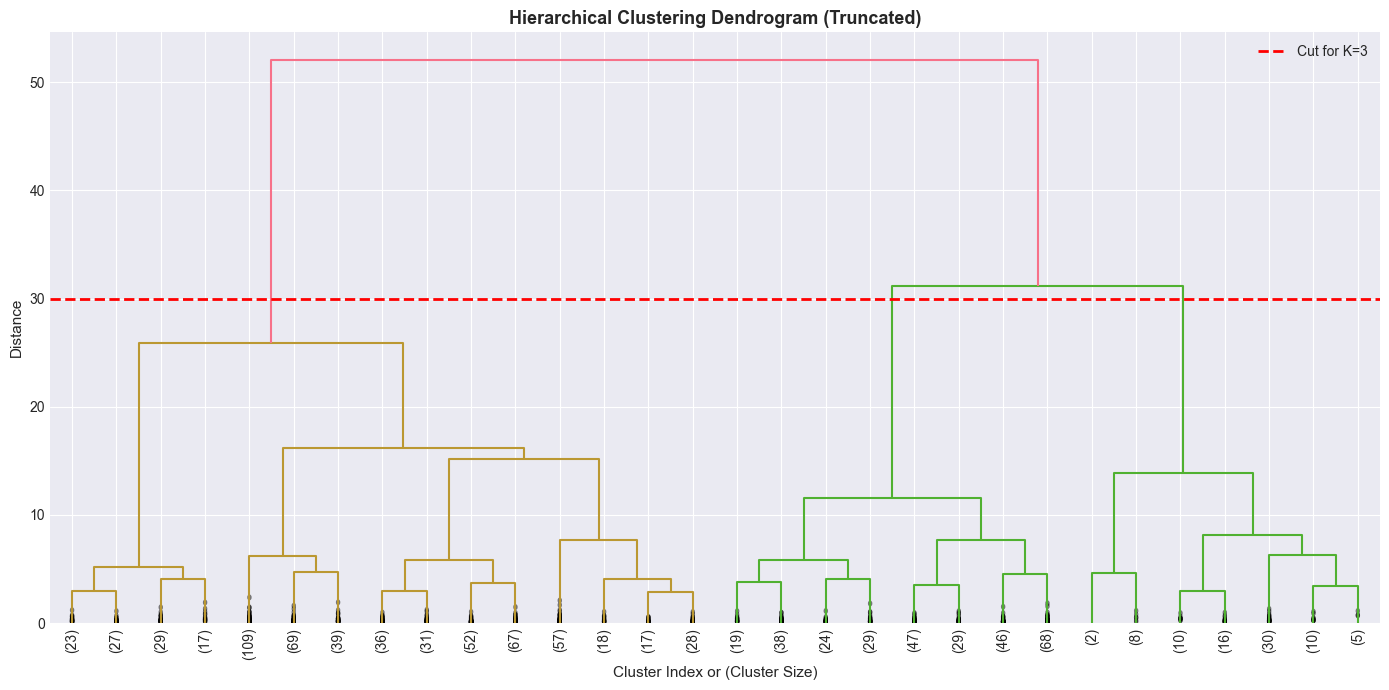


📌 The red dashed line shows where we cut the dendrogram to get 3 clusters
   Points above the line belong to different clusters


In [11]:
# Plot dendrogram
plt.figure(figsize=(14, 7))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,  # show last 30 merges
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Truncated)', fontsize=13, fontweight='bold')
plt.xlabel('Cluster Index or (Cluster Size)', fontsize=11)
plt.ylabel('Distance', fontsize=11)
plt.axhline(y=30, c='red', linestyle='--', label='Cut for K=3', linewidth=2)
plt.legend()
plt.tight_layout()
plt.show()

print("\n📌 The red dashed line shows where we cut the dendrogram to get 3 clusters")
print("   Points above the line belong to different clusters")

In [12]:
# Apply hierarchical clustering with K=3
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_clusters = hierarchical.fit_predict(rfm_scaled)

# Add to RFM dataframe
rfm['Hierarchical_Cluster'] = hierarchical_clusters

print(f"Hierarchical Clustering with K=3")
print(f"\nCluster distribution:")
print(rfm['Hierarchical_Cluster'].value_counts().sort_index())
print(f"\nCluster percentages:")
print((rfm['Hierarchical_Cluster'].value_counts(normalize=True).sort_index() * 100).round(2))

Hierarchical Clustering with K=3

Cluster distribution:
Hierarchical_Cluster
0    619
1     81
2    300
Name: count, dtype: int64

Cluster percentages:
Hierarchical_Cluster
0    61.9
1     8.1
2    30.0
Name: proportion, dtype: float64


## 🎯 Class Exercise 2: Compare K-Means vs Hierarchical Clustering

**Task**: Compare the two clustering methods

1. **Are the cluster assignments the same?** Calculate the Adjusted Rand Index (ARI) to measure agreement.
2. **Which method do you prefer and why?**
   - K-Means: Fast, scalable, but need to specify K in advance
   - Hierarchical: Shows relationships, dendrogram visualization, but slower
3. **Look at the dendrogram.** Can you identify natural cluster boundaries?

In [13]:
# Compare clustering methods
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(kmeans_clusters, hierarchical_clusters)
nmi = normalized_mutual_info_score(kmeans_clusters, hierarchical_clusters)

print(f"Comparison Metrics:")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")
print(f"\nInterpretation:")
print(f"ARI = 1: Perfect agreement")
print(f"ARI = 0: Random clustering")
print(f"ARI < 0: Worse than random\n")

# Confusion matrix between the two methods
cm = pd.crosstab(kmeans_clusters, hierarchical_clusters, 
                   rownames=['K-Means'], colnames=['Hierarchical'])
print(f"\nCrosstab of cluster assignments:")
print(cm)

Comparison Metrics:
Adjusted Rand Index: 0.4920
Normalized Mutual Information: 0.5628

Interpretation:
ARI = 1: Perfect agreement
ARI = 0: Random clustering
ARI < 0: Worse than random


Crosstab of cluster assignments:
Hierarchical    0   1    2
K-Means                   
0               0  77   15
1             460   3    0
2             159   1  285


# Part 3: Principal Component Analysis (PCA)

PCA reduces dimensionality while preserving variance. Let's see how our RFM data can be represented in 2D for visualization.

In [14]:
# Apply PCA
pca = PCA()
pca_result = pca.fit_transform(rfm_scaled)

# Calculate cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

print("PCA Results:")
print(f"Number of original features: {rfm_scaled.shape[1]}")
print(f"\nExplained variance by each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"\nCumulative explained variance:")
for i, var in enumerate(cumsum_var):
    print(f"PC1-PC{i+1}: {var:.4f} ({var*100:.2f}%)")

PCA Results:
Number of original features: 3

Explained variance by each component:
PC1: 0.6840 (68.40%)
PC2: 0.2342 (23.42%)
PC3: 0.0818 (8.18%)

Cumulative explained variance:
PC1-PC1: 0.6840 (68.40%)
PC1-PC2: 0.9182 (91.82%)
PC1-PC3: 1.0000 (100.00%)


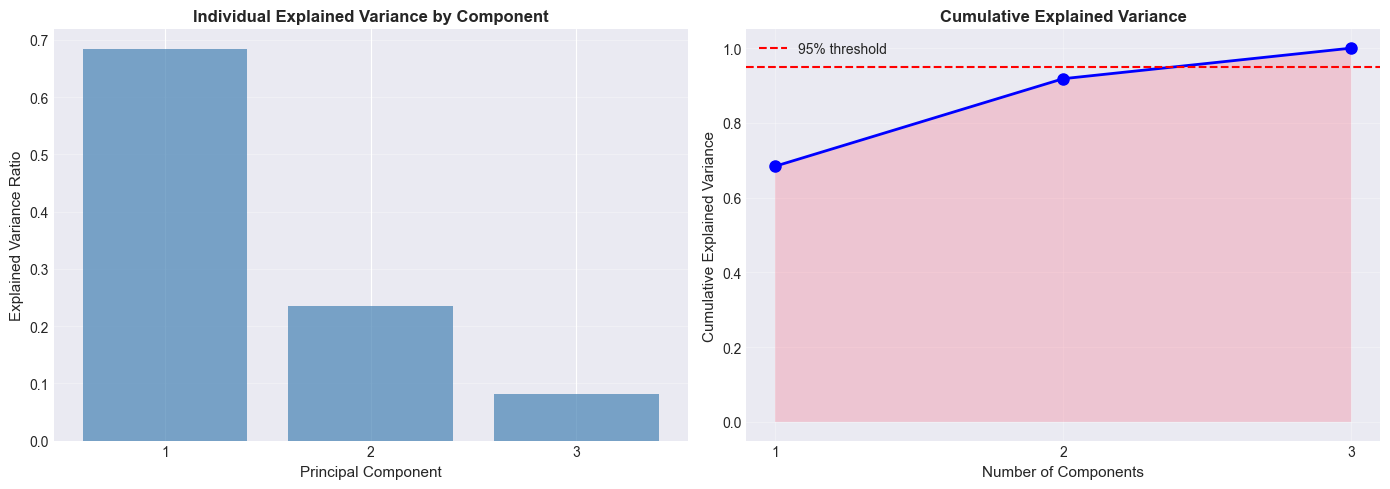

In [15]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
             pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=11)
axes[0].set_title('Individual Explained Variance by Component', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative explained variance
axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].fill_between(range(1, len(cumsum_var) + 1), cumsum_var, alpha=0.3)
axes[1].set_xlabel('Number of Components', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(1, len(cumsum_var) + 1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

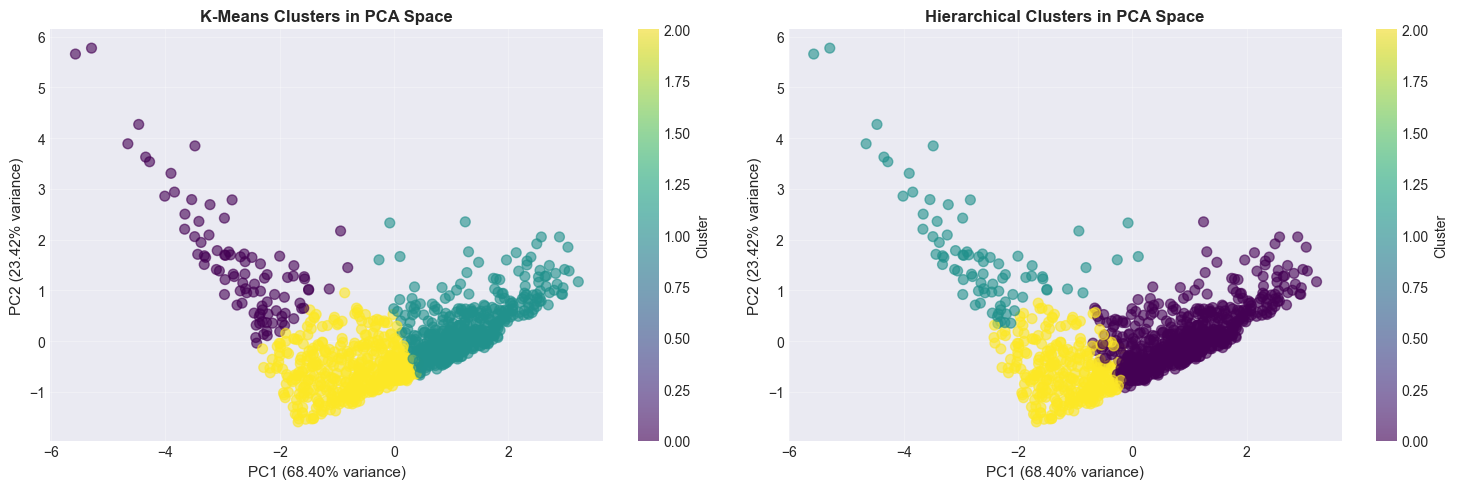


2D PCA Explained Variance: 91.82%


In [16]:
# Visualize data in 2D using PCA
pca_2d = PCA(n_components=2)
pca_2d_result = pca_2d.fit_transform(rfm_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# K-Means clusters in PCA space
scatter1 = axes[0].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], 
                           c=kmeans_clusters, cmap='viridis', alpha=0.6, s=50)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=11)
axes[0].set_title('K-Means Clusters in PCA Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')
axes[0].grid(True, alpha=0.3)

# Hierarchical clusters in PCA space
scatter2 = axes[1].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], 
                           c=hierarchical_clusters, cmap='viridis', alpha=0.6, s=50)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=11)
axes[1].set_title('Hierarchical Clusters in PCA Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n2D PCA Explained Variance: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

In [17]:
# Analyze PCA loadings (feature contributions)
loadings = pca_2d.components_.T * np.sqrt(pca_2d.explained_variance_)
loading_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=['Recency', 'Frequency', 'Monetary']
)

print("\nPCA Loadings (Feature Contributions):")
print(loading_df.round(4))
print("\nInterpretation:")
print("- Higher absolute loading = stronger contribution to that PC")
print(f"- PC1 explains {pca_2d.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"- PC2 explains {pca_2d.explained_variance_ratio_[1]*100:.2f}% of variance")


PCA Loadings (Feature Contributions):
              PC1     PC2
Recency   -0.6857  0.7243
Frequency  0.9129  0.1820
Monetary   0.8662  0.3815

Interpretation:
- Higher absolute loading = stronger contribution to that PC
- PC1 explains 68.40% of variance
- PC2 explains 23.42% of variance


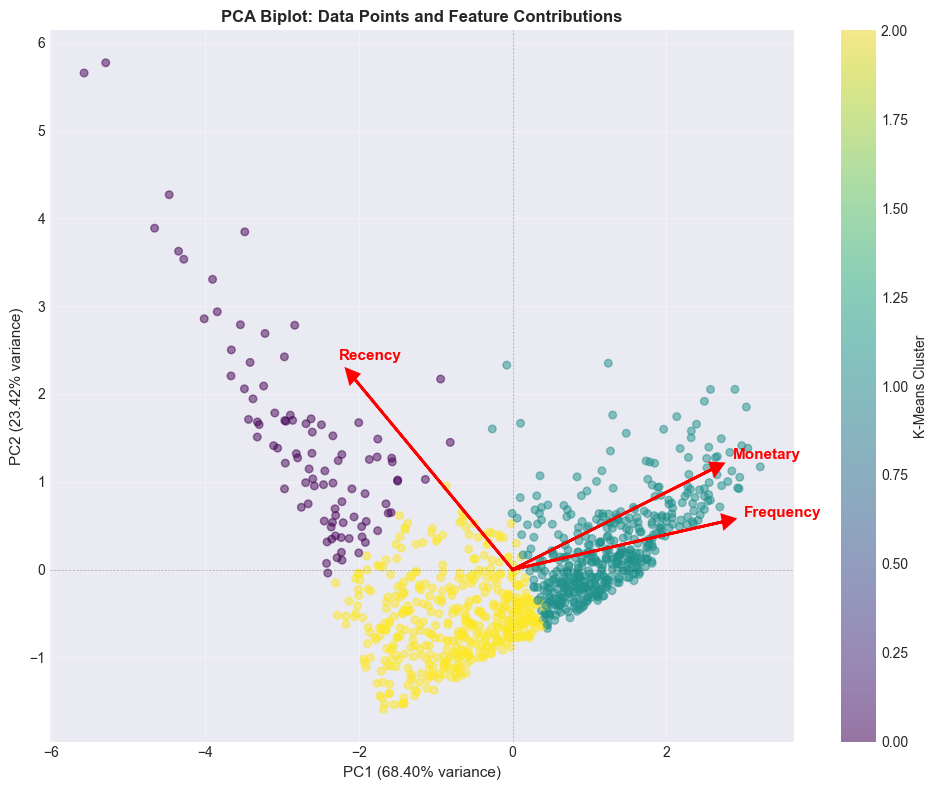


📌 Biplot Interpretation:
- Arrow length = importance in PC
- Arrow direction = how feature varies in PC space
- Close arrows = correlated features


In [18]:
# Create a biplot (showing both data points and feature vectors)
fig, ax = plt.subplots(figsize=(10, 8))

# Plot data points
scatter = ax.scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], 
                      c=kmeans_clusters, cmap='viridis', alpha=0.5, s=30)

# Plot feature vectors
features = ['Recency', 'Frequency', 'Monetary']
for i, feature in enumerate(features):
    ax.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, 
            head_width=0.15, head_length=0.15, fc='red', ec='red', linewidth=2)
    ax.text(loadings[i, 0]*3.3, loadings[i, 1]*3.3, feature, 
           fontsize=11, fontweight='bold', color='red')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=11)
ax.set_title('PCA Biplot: Data Points and Feature Contributions', fontsize=12, fontweight='bold')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='K-Means Cluster')
plt.tight_layout()
plt.show()

print("\n📌 Biplot Interpretation:")
print("- Arrow length = importance in PC")
print("- Arrow direction = how feature varies in PC space")
print("- Close arrows = correlated features")

In [19]:
# Isolation Forest - another anomaly detection method
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_predictions = iso_forest.fit_predict(rfm_scaled)
iso_scores = iso_forest.score_samples(rfm_scaled)

rfm['IsoForest_Anomaly'] = iso_predictions
rfm['IsoForest_Score'] = iso_scores

print(f"Isolation Forest Results:")
print(f"Normal customers: {(iso_predictions == 1).sum()}")
print(f"Anomalies: {(iso_predictions == -1).sum()}")
print(f"Anomaly percentage: {(iso_predictions == -1).sum() / len(iso_predictions) * 100:.2f}%")

# Show top 10 anomalies
anomalies_iso = rfm[rfm['IsoForest_Anomaly'] == -1].sort_values('IsoForest_Score').head(10)
print(f"\nTop 10 Anomalies (Isolation Forest):")
print(anomalies_iso[['Recency', 'Frequency', 'Monetary', 'IsoForest_Score']])

Isolation Forest Results:
Normal customers: 950
Anomalies: 50
Anomaly percentage: 5.00%

Top 10 Anomalies (Isolation Forest):
            Recency  Frequency       Monetary  IsoForest_Score
CustomerID                                                    
757             217          6    7888.231314        -0.743004
591             215          6   31632.261061        -0.725613
818             165          5    7616.753526        -0.706128
129             170          5   35147.631139        -0.696968
908             149         13   54433.634317        -0.689193
852             134          7    4670.856102        -0.677535
429              26         49  279288.789271        -0.676660
353             155          6   15018.187016        -0.670791
59              152          6   16216.956370        -0.668363
894              31         49  257431.729498        -0.662484


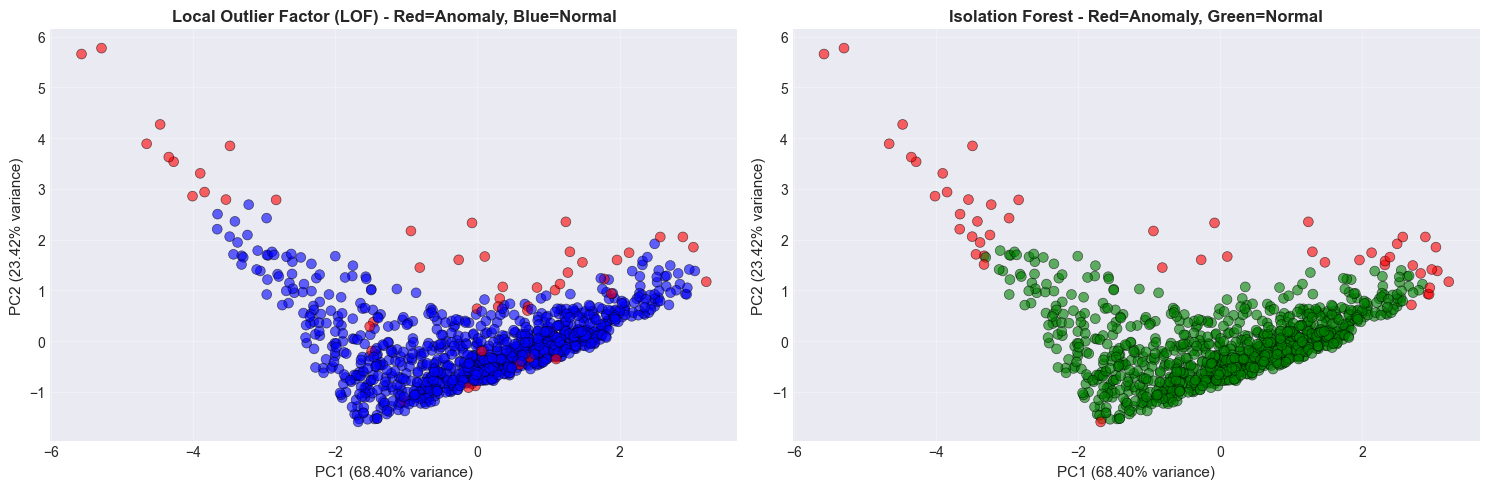

In [23]:
# Visualize anomalies in PCA space
# Make this cell robust to out-of-order execution.
if 'lof_predictions' not in globals():
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
    lof_predictions = lof.fit_predict(rfm_scaled)

if 'iso_predictions' not in globals():
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    iso_predictions = iso_forest.fit_predict(rfm_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LOF Anomalies
colors_lof = ['red' if x == -1 else 'blue' for x in lof_predictions]
axes[0].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], c=colors_lof, 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=11)
axes[0].set_title('Local Outlier Factor (LOF) - Red=Anomaly, Blue=Normal', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Isolation Forest Anomalies
colors_iso = ['red' if x == -1 else 'green' for x in iso_predictions]
axes[1].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], c=colors_iso, 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=11)
axes[1].set_title('Isolation Forest - Red=Anomaly, Green=Normal', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Compare the two methods
from sklearn.metrics import adjusted_rand_score

# Convert -1/1 to 0/1 for comparison
lof_binary = (lof_predictions == -1).astype(int)
iso_binary = (iso_predictions == -1).astype(int)

agreement = (lof_binary == iso_binary).sum() / len(lof_binary)
both_anomaly = (lof_binary & iso_binary).sum()
lof_only = (lof_binary & ~iso_binary).sum()
iso_only = (~lof_binary & iso_binary).sum()

print(f"Comparison of Anomaly Detection Methods:")
print(f"\nAgreement: {agreement*100:.2f}%")
print(f"Detected by both: {both_anomaly}")
print(f"Detected by LOF only: {lof_only}")
print(f"Detected by Isolation Forest only: {iso_only}")
print(f"\nConfusion Matrix:")
cm_anom = pd.crosstab(lof_binary, iso_binary, 
                        rownames=['LOF'], colnames=['IsoForest'])
print(cm_anom)

Comparison of Anomaly Detection Methods:

Agreement: 95.20%
Detected by both: 26
Detected by LOF only: 24
Detected by Isolation Forest only: 24

Confusion Matrix:
IsoForest    0   1
LOF               
0          926  24
1           24  26


# Part 5: Cross-Validation Strategies

Cross-validation helps us evaluate model performance reliably and avoid overfitting. Let's explore different strategies.

In [25]:
# For cross-validation, we need a supervised learning task
# Let's create a classification task: predict if customer is high-value

# Create target: High-value if monetary value in top 30%
threshold = rfm['Monetary'].quantile(0.70)
y = (rfm['Monetary'] > threshold).astype(int)
X = rfm_scaled

print(f"Classification Task: Predicting High-Value Customers")
print(f"Threshold: {threshold:.2f}")
print(f"\nClass distribution:")
print(f"Not High-Value (0): {(y == 0).sum()} ({(y == 0).mean()*100:.2f}%)")
print(f"High-Value (1): {(y == 1).sum()} ({(y == 1).mean()*100:.2f}%)")

Classification Task: Predicting High-Value Customers
Threshold: 109390.40

Class distribution:
Not High-Value (0): 700 (70.00%)
High-Value (1): 300 (30.00%)


In [27]:
# Compare different cross-validation strategies
from sklearn.model_selection import (KFold, StratifiedKFold, 
                                      ShuffleSplit, LeaveOneOut)

# Define a simple classifier for testing
clf = RandomForestClassifier(n_estimators=50, random_state=42)

# Define CV strategies
cv_strategies = {
    'K-Fold (k=5)': KFold(n_splits=5, shuffle=True, random_state=42),
    'K-Fold (k=10)': KFold(n_splits=10, shuffle=True, random_state=42),
    'Stratified K-Fold (k=5)': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'Shuffle Split (5 iter, 0.2 test)': ShuffleSplit(n_splits=5, test_size=0.2, random_state=42),
}

cv_results = {}

for cv_name, cv_strategy in cv_strategies.items():
    scores = cross_val_score(clf, X, y, cv=cv_strategy, scoring='accuracy')
    cv_results[cv_name] = scores
    print(f"\n{cv_name}:")
    print(f"  Scores: {scores}")
    print(f"  Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")


K-Fold (k=5):
  Scores: [1.    1.    1.    1.    0.995]
  Mean: 0.9990, Std: 0.0020

K-Fold (k=10):
  Scores: [1.   1.   1.   1.   1.   1.   1.   1.   1.   0.99]
  Mean: 0.9990, Std: 0.0030

Stratified K-Fold (k=5):
  Scores: [1.    1.    0.995 1.    0.995]
  Mean: 0.9980, Std: 0.0024

Shuffle Split (5 iter, 0.2 test):
  Scores: [1.    1.    0.99  0.995 1.   ]
  Mean: 0.9970, Std: 0.0040


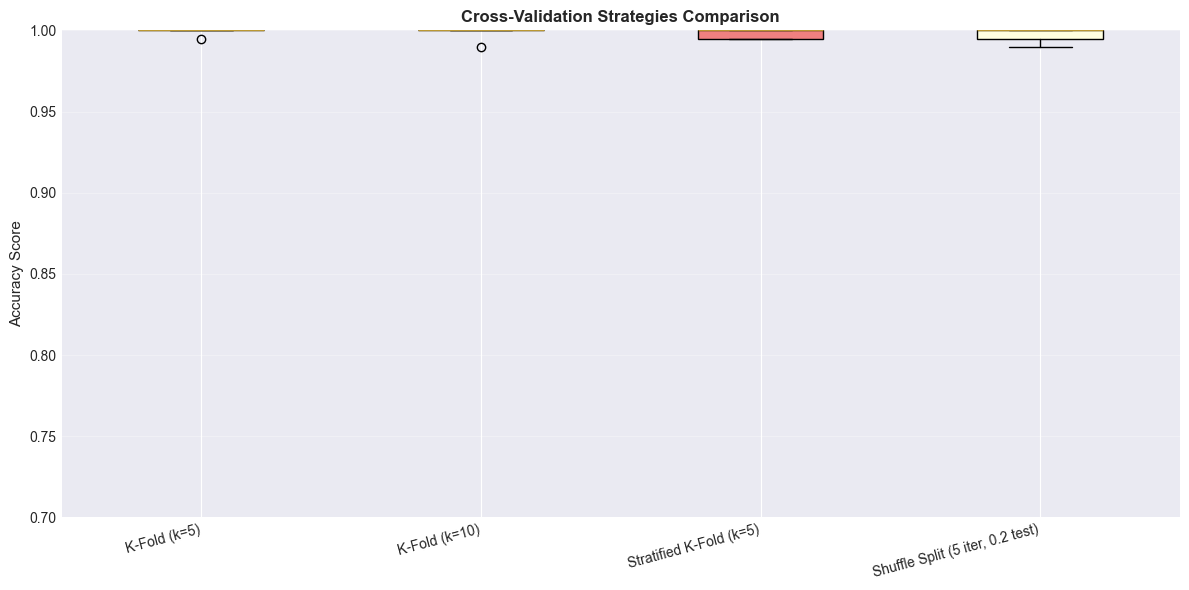

In [28]:
# Visualize cross-validation results
fig, ax = plt.subplots(figsize=(12, 6))

positions = range(len(cv_results))
cv_names = list(cv_results.keys())
cv_scores = list(cv_results.values())

bp = ax.boxplot(cv_scores, labels=cv_names, patch_artist=True)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Accuracy Score', fontsize=11)
ax.set_title('Cross-Validation Strategies Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([0.7, 1.0])
plt.xticks(rotation=15, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

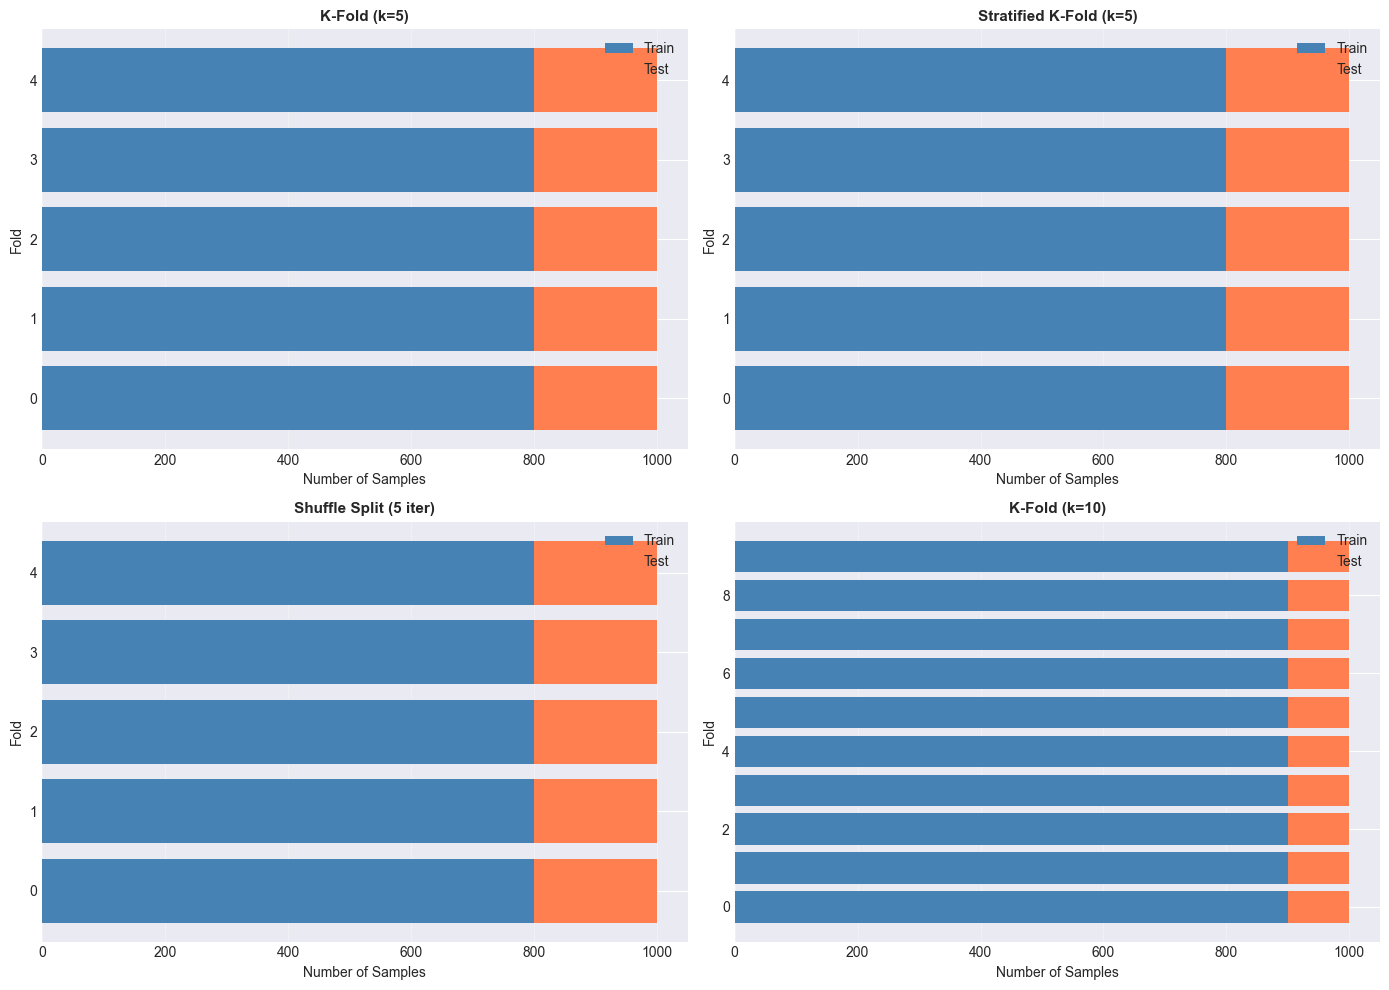


Cross-Validation Strategies:

1. K-Fold: Divide data into k folds, train on k-1, test on 1
   - Simple, but may not preserve class distribution

2. Stratified K-Fold: Like K-Fold but preserves class distribution
   - Better for imbalanced datasets

3. Shuffle Split: Random train/test splits
   - Flexible, useful for large datasets

4. Leave-One-Out: n-fold CV where n = dataset size
   - Computationally expensive, low bias but high variance


In [29]:
# Visualize fold splits
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cv_strategies_plot = [
    ('K-Fold (k=5)', KFold(n_splits=5, shuffle=True, random_state=42)),
    ('Stratified K-Fold (k=5)', StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
    ('Shuffle Split (5 iter)', ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)),
    ('K-Fold (k=10)', KFold(n_splits=10, shuffle=True, random_state=42)),
]

for idx, (cv_name, cv_strategy) in enumerate(cv_strategies_plot):
    ax = axes[idx]
    
    # Visualize splits
    for i, (train_idx, test_idx) in enumerate(cv_strategy.split(X, y)):
        sizes = [len(train_idx), len(test_idx)]
        ax.barh(i, sizes[0], left=0, height=0.8, label='Train' if i == 0 else '', color='steelblue')
        ax.barh(i, sizes[1], left=sizes[0], height=0.8, label='Test' if i == 0 else '', color='coral')
    
    ax.set_ylabel('Fold', fontsize=10)
    ax.set_xlabel('Number of Samples', fontsize=10)
    ax.set_title(cv_name, fontsize=11, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nCross-Validation Strategies:")
print("\n1. K-Fold: Divide data into k folds, train on k-1, test on 1")
print("   - Simple, but may not preserve class distribution")
print("\n2. Stratified K-Fold: Like K-Fold but preserves class distribution")
print("   - Better for imbalanced datasets")
print("\n3. Shuffle Split: Random train/test splits")
print("   - Flexible, useful for large datasets")
print("\n4. Leave-One-Out: n-fold CV where n = dataset size")
print("   - Computationally expensive, low bias but high variance")

# Part 6: Hyperparameter Tuning - Grid Search vs Random Search

This section compares exhaustive and stochastic tuning strategies on the same model and dataset.

In [31]:
# Define search space
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

total = 1
for values in param_grid.values():
    total *= len(values)

print(f'Total grid combinations: {total}')
for k, v in param_grid.items():
    print(f'{k}: {v}')

Total grid combinations: 162
n_estimators: [50, 100, 200]
max_depth: [5, 10, None]
min_samples_split: [2, 5, 10]
min_samples_leaf: [1, 2, 4]
max_features: ['sqrt', 'log2']


In [32]:
# Grid Search
start_grid = time.time()
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X, y)
grid_time = time.time() - start_grid

print('Grid Search complete')
print(f'Time: {grid_time:.2f}s')
print(f'Best score: {grid_search.best_score_:.4f}')
print(f'Best params: {grid_search.best_params_}')

Grid Search complete
Time: 10.69s
Best score: 1.0000
Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


In [33]:
# Random Search
start_random = time.time()
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X, y)
random_time = time.time() - start_random

print('Random Search complete')
print(f'Time: {random_time:.2f}s')
print(f'Best score: {random_search.best_score_:.4f}')
print(f'Best params: {random_search.best_params_}')

Random Search complete
Time: 1.14s
Best score: 1.0000
Best params: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5}


          Method  Best CV Score   Time (s)  Configs Tested
0    Grid Search            1.0  10.691296             162
1  Random Search            1.0   1.135595              20

Speedup (Grid/Random): 9.41x
Score gap: 0.0000


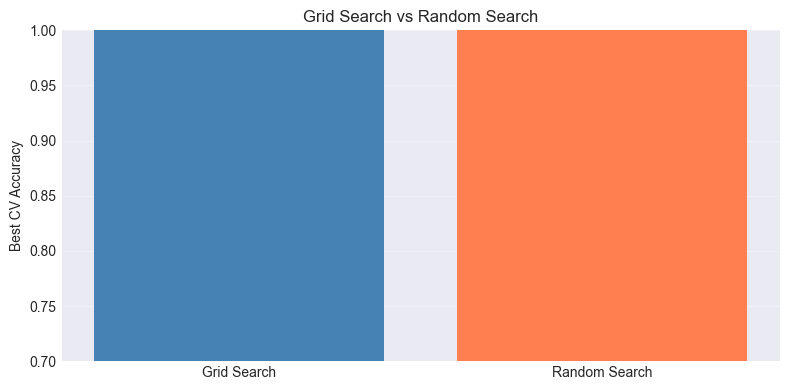

In [34]:
# Compare Grid vs Random search
summary = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Time (s)': [grid_time, random_time],
    'Configs Tested': [len(grid_search.cv_results_['params']), len(random_search.cv_results_['params'])]
})

print(summary)
print(f"\nSpeedup (Grid/Random): {grid_time / random_time:.2f}x")
print(f"Score gap: {abs(grid_search.best_score_ - random_search.best_score_):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary['Method'], summary['Best CV Score'], color=['steelblue', 'coral'])
ax.set_ylim(0.70, 1.0)
ax.set_ylabel('Best CV Accuracy')
ax.set_title('Grid Search vs Random Search')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## When Tuning Is a Waste of Time

If the improvement from tuning is tiny, time is better spent on data cleaning, feature engineering, or collecting better labels.

In [35]:
# Quantify tuning benefit
default_model = RandomForestClassifier(random_state=42)
default_score = cross_val_score(default_model, X, y, cv=5, scoring='accuracy').mean()
tuned_model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
tuned_score = cross_val_score(tuned_model, X, y, cv=5, scoring='accuracy').mean()

delta = (tuned_score - default_score) * 100
print(f'Default CV score: {default_score:.4f}')
print(f'Tuned CV score:   {tuned_score:.4f}')
print(f'Improvement:      {delta:.2f}%')

if abs(delta) < 1.0:
    print('Recommendation: skip heavy tuning and focus on features/data quality.')
else:
    print('Recommendation: tuning is likely worth the effort.')

Default CV score: 0.9990
Tuned CV score:   1.0000
Improvement:      0.10%
Recommendation: skip heavy tuning and focus on features/data quality.


# Part 7: Lab - Structured Hyperparameter Experiments

We now run a controlled experiment over two key hyperparameters and visualize their interactions.

Mean CV accuracy table:
        50     100    200    300
5     0.999  0.999  0.999  0.998
10    1.000  0.999  0.999  0.999
15    0.999  0.999  0.999  0.999
None  0.999  0.999  0.999  0.999


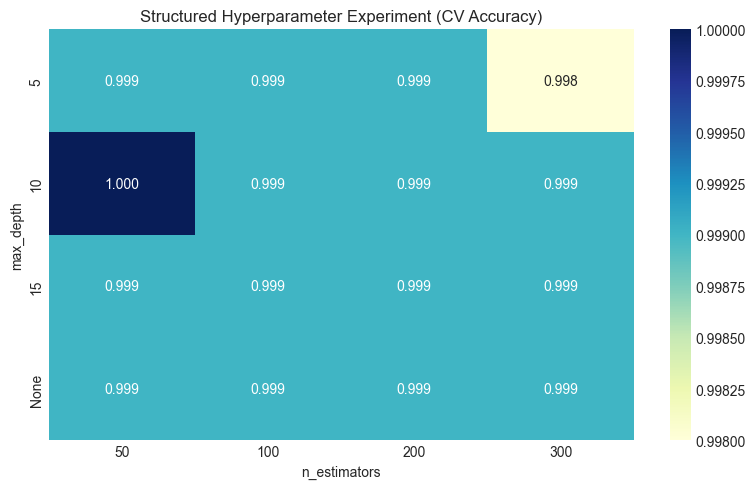

In [36]:
# Structured experiment over n_estimators and max_depth
n_estimators_list = [50, 100, 200, 300]
max_depth_list = [5, 10, 15, None]

score_matrix = np.zeros((len(max_depth_list), len(n_estimators_list)))

for i, depth in enumerate(max_depth_list):
    for j, n_est in enumerate(n_estimators_list):
        model = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            random_state=42
        )
        score_matrix[i, j] = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()

heatmap_df = pd.DataFrame(
    score_matrix,
    index=[str(d) for d in max_depth_list],
    columns=n_estimators_list
)

print('Mean CV accuracy table:')
print(heatmap_df)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
ax.set_title('Structured Hyperparameter Experiment (CV Accuracy)')
plt.tight_layout()
plt.show()

## Class Exercise: Tuning Game

1. Run the structured experiment cell and identify the best score.
2. Compare the fastest configuration (smallest model) against the best score configuration.
3. Decide if the extra accuracy gain is worth the extra computation.
4. Bonus: increase n_estimators to 500 and check if returns are diminishing.